# 심층 신경망 훈련 

### 깊은 신경망을 훈련하기 위한 문제 
- 출력층에서 멀어질수록 그레디언트가 커지거나 작아지는 문제 
- 대규모 신경망을 위한 훈련 데이터가 충분하지 않거나 레이블 작업 비용이 너무 많이듦
- 훈련이 극단적으로 느려짐 
- 수 많은 파라미터를 가진 모델은 과대적합의 위험이 있음

### 해결방법 
- 전이 학습 
- 비지도 사전 훈련 
- 최적화 
- 대규모 신경망을 위한 규제 기법

# 1. 그레디언트 소실/폭주 문제 

## 정의 
- 그레디언트 소실: 역전파 과정에서 가중치 업데이트에 사용되는 그레디언트가 너무 작아져서 학습이 제대로 이루어지지 않는 현상
- 그레디언트 폭주: 그레디언트가 너무 커져서 가중치 업데이트가 불안정해지는 현상
  - 주로 순환 신경망에서 발생 

## 원인 
- `로지스틱 시그모이드 활성화 함수`와 `가중치 초기화 방식`의 조합 
  - 출력의 분산이 입력의 분산보다 더 큼
  - 신경망의 위쪽으로 갈 수록 층을 지날 때마다 분산이 계속 커짐 
  - 가장 높은 층에서는 활성화 함수가 0이나 1로 수렴 
  
### 시그모이드 함수의 문제 
- 시그모이드 함수의 평균 : 0.5 
- 입력이 커지면 출력이 0이나 1로 수렴
- 역전파 할 그레디언트가 없음 -> 아래층에는 아무것도 전달되지 않음

- 그래프를 그리기 위한 matplotlib 작성

In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib
import sys
import warnings
# UserWarning 카테고리의 모든 경고를 무시
warnings.filterwarnings("ignore", category=UserWarning)

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

- 시그모이드 활성화 함수의 수렴

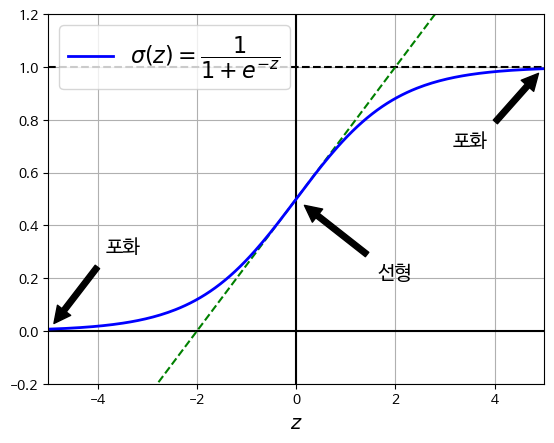

In [6]:
# 추가 코드 - 이 셀은 그림 11-1을 생성하고 저장합니다.

import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-5, 5, 200)

plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [1, 1], 'k--')
plt.plot([0, 0], [-0.2, 1.2], 'k-')
plt.plot([-5, 5], [-3/4, 7/4], 'g--')
plt.plot(z, sigmoid(z), "b-", linewidth=2,
         label=r"$\sigma(z) = \dfrac{1}{1+e^{-z}}$")
props = dict(facecolor='black', shrink=0.1)
plt.annotate('포화', xytext=(3.5, 0.7), xy=(5, 1), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('포화', xytext=(-3.5, 0.3), xy=(-5, 0), arrowprops=props,
             fontsize=14, ha="center")
plt.annotate('선형', xytext=(2, 0.2), xy=(0, 0.5), arrowprops=props,
             fontsize=14, ha="center")
plt.grid(True)
plt.axis([-5, 5, -0.2, 1.2])
plt.xlabel("$z$")
plt.legend(loc="upper left", fontsize=16)

plt.show()

----

## 글로럿과 He 초기화
### 가정
- 각 층의 출력에 대한 분산이 입력에 대한 분산과 같아야 역전파 시 양방향 신호가 적절하게 흐른다고 가정
- 역방향에서 층을 통과하기 위해 전과 후 그레디언트 분산이 동일해야함
- `팬 인`(층 입력 갯수)과 `팬 아웃`(출력 연결 갯수)가 같지 않으면 위 가정들을 보장 할 수 없음

### 글로럿 초기화
- 연결 가중치를 `랜덤`하게 초기화

#### 글로럿 초기화 공식
- 가정 : 시그모이드 활성화 함수 사용
- $fan_{\textrm{avg}}=(fan_{\textrm{in}}+fan_{\textrm{out}})/2$
- 아래와 같은 정규분포에서 랜덤하게 초기화 
  - 평균 = 0 
  - 분산 = $\sigma^2 = \frac{1}{fan_{\textrm{avg}}}$ 
- 혹은 아래와 같은 균등 분포에서 초기화 
  - $-r$ 과 $r$  사이 균등 분포 
  - 이때, $r=\sqrt{\frac{3}{fan_{\textrm{avg}}}}$

### 르쿤 초기화 
- 글로럿 초기화에서 $fan_{\textrm{avg}}$을 $fan_{\textrm{in}}$ 으로 변경 
  - $fan_{\textrm{in}} = fan_{\textrm{out}} $ 이면, `글로럿 초기화 = 르쿤 초기화`

### He 초기화 (카이밍 초기화)
- `ReLU`  활성화 함수와 이를 위한 초기화 전략을 사용 

|초기화 전략|활성화 전략|정규분포|
|---|---|---|
|글로럿|활성화 함수 없음, tanh, 로지스틱, 소프트맥스| $1/fan_{\textrm{avg}}$|
|르쿤|SELU| $1/fan_{\textrm{in}}$|
|He|ReLU, LeakyReLU, ELU, GELU,Swish,  Mish| $2/fan_{\textrm{in}}$|

### 케라스를 통한 초기화
- `kernel_initializer='he_uniform'` OR `he_normal`로 하면 He 초기화 사용 가능 
- `VarianceScaling` : 다른 초기화 방법 사용

In [7]:
import tensorflow as tf 

### He 초기화 
dense =tf.keras.layers.Dense(50, activation='relu',kernel_initializer="he_normal")

### 초기화 방식 변경 : fan_out 기반 He 초기화 
he_avg_init = tf.keras.initializers.VarianceScaling(
    scale=2.0, mode='fan_out', distribution='uniform')

dense = tf.keras.layers.Dense(50,activation="sigmoid",kernel_initializer=he_avg_init)

## 고급 활성화 함수
- 활성화 함수를 잘못 선택하면 그레이디언트 소실이나 폭주로 이어질 수 있음
- 기존에는 시그모이드, ReLU 등이 사용되었으나 이 것도 완벽하지 않음 

### 죽은 ReLU 문제 
- 일부 뉴런이 0 이외의 값을 출력하지 않음 
- 학습률이 클 수록 뉴런이 죽어 있는 비율이 커짐 


### Leaky ReLU
#### 정의 
$\textrm{LeakyReLU}_a(z) =  \textrm{max} (\alpha \cdot z, z)$

#### 새는 정도
- $\alpha$ : 함수가 `새는` 정도 
- `새는 정도` : $z < 0$ 일 때 함수의 기울기 
- $z < 0$일 때 기울기가 절대 죽지 않게 만듦 
- 다시 깨어날 가능성을 얻음 
- $\alpha=0.2$ 가 $\alpha=0.01$보다 더 나은 성능을 보임

#### 단점 
- 소규모 데이터셋에서는 훈련세트에 과대 적합이 될 위험이 있음 


- LeakReLU 그래프 

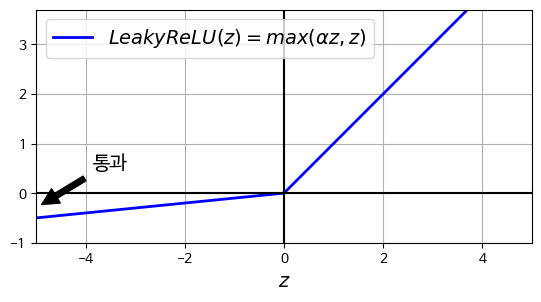

In [9]:
def leaky_relu(z, alpha):
    return np.maximum(alpha * z, z)

z = np.linspace(-5, 5, 200)
plt.plot(z, leaky_relu(z, 0.1), "b-", linewidth=2, label=r"$LeakyReLU(z) = max(\alpha z, z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([0, 0], [-1, 3.7], 'k-')
plt.grid(True)
props = dict(facecolor='black', shrink=0.1)
plt.annotate('통과', xytext=(-3.5, 0.5), xy=(-5, -0.3), arrowprops=props,
             fontsize=14, ha="center")
plt.xlabel("$z$")
plt.axis([-5, 5, -1, 3.7])
plt.gca().set_aspect("equal")
plt.legend()

plt.show()

-  케라스를 통한 LeajyReLU 구현
- He 초기화 사용 

In [10]:
### leaky ReLU 레이어 생성
leaky_relu=tf.keras.layers.LeakyReLU(alpha=0.2)

### 층 생성 
dense = tf.keras.layers.Dense(50, activation=leaky_relu,kernel_initializer="he_normal")

### 별도 층으로 모델 추가 
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(50, kernel_initializer="he_normal"),  # 활성화 함수 없음
    tf.keras.layers.LeakyReLU(alpha=0.2),  # 별도의 층으로 활성화 함수 추가
])

## ELU와 SELU
### leaky ReLU , PReLu의 단점 
- `매끄러운 함수`가 아님 
    - `매끄러운 함수` 가 아님: 도함수가 $z=0$ 일 때, 갑자기 바뀜 
    - 불연속성이 있음 -> 경사하강법의 최적점을 진동하게 만들거나 수렴을 느리게 만듦 
    - `부드로운` 변형이 필요함 
    
    
### ELU
#### 정의 
$\textrm{ELU}_\alpha(z) = \begin{cases} z & \text{if } z \geq 0 \\ \alpha (\textrm{exp(z)} - 1) & \text{if } z < 0 \end{cases}$

#### ReLU와의 차이점 
- $z<0$ 일 때, 음수값 -> 활성함수의 평균 출력이 0에 가까워짐 -> 그레디언트 소실 문제 완화 
- 하이퍼파라미터 $\alpha$눈 $z$가 큰 음숫값 일 때, ELU가 수렴 할 값의 역수를 정의 
- $z<0$ 이어도 그레디언트가 0 아님 -> 죽은 뉴런을 만들지 않음 
- $\alpha=1$ 이면 $z=0$에서 급격히 변동 하지 않음 -> 모든 구간에서 매끄러워 경사하강법의 속도를 높임 

#### 단점 
- 지수 함수를 사용하기 때문에 계산이 느림 

#### keras에서 ELU 사용 
- `activation="elu"` 

In [11]:
dense = tf.keras.layers.Dense(50, activation="elu",
                              kernel_initializer="he_normal")

### SELU
#### 정의 
- 스케일이 조정됨 ELU 활성화 함수의 변형 
- SELU를 사용하면 네트워크가 `자기정규화`됨 ->훈련하는 동안 각 층의 출력이 평균0과 표준편차1을 유지하려는 경향을 보임 

#### 사용 조건 
- 입력 특성은 평균 0, 표준편차 1로 정규화되어야 함
- 모든 은닉층의 가중치는 `lecun_normal` 초기화로 초기화되어야 함
- 자기 정규화는 MLP에서만 보장됨 
-  규제 사용 불가 : $ \ell_1,\ell_2$ 규제, 맥스-노름, 배치 정규화, 드롭아웃

#### 장점
- MLP(매우 깊은 네트워크)에서 높은 성능을 보임 

#### 단점
- 순환 신경망이나 스킵 연결 구조에서는 자기 정규화를 보장하지 못함 -> 성능이 ELU보다 낮을 수 있음 

In [17]:
dense = tf.keras.layers.Dense(50, activation="selu",
                              kernel_initializer="lecun_normal")

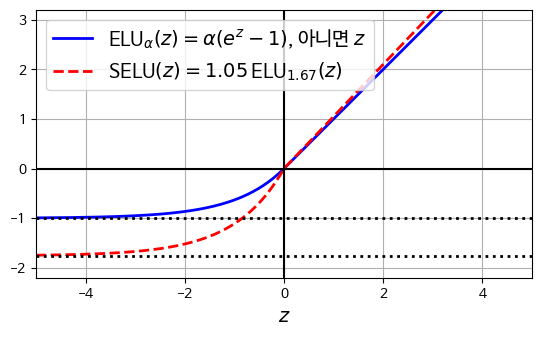

In [16]:
from scipy.special import erfc

# 평균 0, 표준 편차 1로 자체 정규화하기 위한 alpha 및 sacle
# (논문에 있는 식 14 참조):
alpha_0_1 = -np.sqrt(2 / np.pi) / (erfc(1 / np.sqrt(2)) * np.exp(1 / 2) - 1)
scale_0_1 = (
    (1 - erfc(1 / np.sqrt(2)) * np.sqrt(np.e))
    * np.sqrt(2 * np.pi)
    * (
        2 * erfc(np.sqrt(2)) * np.e ** 2
        + np.pi * erfc(1 / np.sqrt(2)) ** 2 * np.e
        - 2 * (2 + np.pi) * erfc(1 / np.sqrt(2)) * np.sqrt(np.e)
        + np.pi
        + 2
    ) ** (-1 / 2)
)

def elu(z, alpha=1):
    return np.where(z < 0, alpha * (np.exp(z) - 1), z)

def selu(z, scale=scale_0_1, alpha=alpha_0_1):
    return scale * elu(z, alpha)

z = np.linspace(-5, 5, 200)
plt.plot(z, elu(z), "b-", linewidth=2, label=r"ELU$_\alpha(z) = \alpha (e^z - 1)$, 아니면 $z$")
plt.plot(z, selu(z), "r--", linewidth=2, label=r"SELU$(z) = 1.05 \, $ELU$_{1.67}(z)$")
plt.plot([-5, 5], [0, 0], 'k-')
plt.plot([-5, 5], [-1, -1], 'k:', linewidth=2)
plt.plot([-5, 5], [-1.758, -1.758], 'k:', linewidth=2)
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-5, 5, -2.2, 3.2])
plt.xlabel("$z$")
plt.gca().set_aspect("equal")
plt.legend()

plt.show()

----

## GELU, Swish, Mish 

### GELU
#### 정의 
$\textrm{GELU}(z) = z\cdot\Phi(z)$
- $\Phi(z)$ : 표준 가우스 누적 분포 함수 
  - 평균 0,  표준분포 1인 정규 분포에서 랜덤하게 샘플링한 값이 $z$보다 작거나 같은 확률

- ReLU 활성화 함수의 부드러운 변형
- 다른 함수와 다르게 볼록한 단조 함수가 아님

#### 장점 
- 경사 하강법이 복잡한 작업에서 잘 작동함 

#### 단점 
- 계산량이 더 많으며 성능 향상이 추가 비용이 많아짐

#### 케라스에서 사용 
`activation="gelu"`

### Swish
#### 정의
- SiLU 함수의 변형
 - SiLU : $z\sigma(z)$
- Swish : $\textrm{Swish}_\beta(z) = z \cdot \sigma(\beta z)$

#### 하이퍼 파라미터 $\beta$
- 훈련 가능한 파라미터로 만들고, 경사하강법으로 최적화 가능 
- 튜닝 가능 

#### 단점 
- 데이터에 대한 과대 적합의 위험 존재 

#### 케라스에서 사용 
`activation="swish"`

### Mish
#### 정의
- Swish의 변형
- $\textrm{Mish}(z) = z \cdot \tanh(\textrm{softplus}(z))$
- $\textrm{softplus}(z) = \log(1 + \text{exp(z)})$

#### 장점
- 매끄러움 
- 볼록하지 않고 단조함수가 아님
- $z$가 음수 일 때, Swish와 동일
- $z$가 양수 일 때, GELU와 동일 

#### 케라스에서 사용 
- keras에서 지원하고 있지 않음 
- 사용자 정의 활성화 함수로 구현 가능

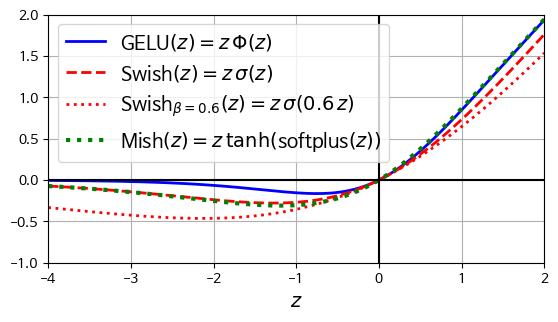

In [19]:
def swish(z, beta=1):
    return z * sigmoid(beta * z)

def approx_gelu(z):
    return swish(z, beta=1.702)

def softplus(z):
    return np.log(1 + np.exp(z))

def mish(z):
    return z * np.tanh(softplus(z))

z = np.linspace(-4, 2, 200)

beta = 0.6
plt.plot(z, approx_gelu(z), "b-", linewidth=2,
         label=r"GELU$(z) = z\,\Phi(z)$")
plt.plot(z, swish(z), "r--", linewidth=2,
         label=r"Swish$(z) = z\,\sigma(z)$")
plt.plot(z, swish(z, beta), "r:", linewidth=2,
         label=fr"Swish$_{{\beta={beta}}}(z)=z\,\sigma({beta}\,z)$")
plt.plot(z, mish(z), "g:", linewidth=3,
         label=fr"Mish$(z) = z\,\tanh($softplus$(z))$")
plt.plot([-4, 2], [0, 0], 'k-')
plt.plot([0, 0], [-2.2, 3.2], 'k-')
plt.grid(True)
plt.axis([-4, 2, -1, 2])
plt.gca().set_aspect("equal")
plt.xlabel("$z$")
plt.legend(loc="upper left")

plt.show()

## 배치 정규화 
### 원리
> 입력을 정규화 한 다음 스케일을 조정하고 이동시킴 

- 각 층에서 활성화 함수를 통과하기 전이나 후에 모델에 연산 추가 
    - 연산 : 입력을 원점에 맞추고 정규화 후 두 개의 새로운 파라미터로 결과 값의 스케일을 조정하고 이동 
    - 파라미터 : 스케일 조정 파라미터, 이동 파라미터
- 배치 정규화를 추가하면, 훈련세트를 표준화 할 필요가 없어짐 

#### 평균과 표준 편차 추정
- 정규화 하려면 평균과 표준 편차 추정 필요 
- 미니 배치에서 입력의 평균과 표준 편차를 계산

##### 평균 $\mu_B$
$\mu_B = \frac{1}{m_B} \sum_{i=1}^{m_B} \mathbf{x}^{(i)}$
- 미니배치 B에 대해서 평가한 입력 평균 벡터 
- $m_B$ : 미니배치 B의 크기(샘플 수)

##### 표준 편차 $\sigma_B^2$
$\sigma_B^2 = \frac{1}{m_B} \sum_{i=1}^{m_B} (\mathbf{x}^{(i)} - \mu_B)^2$
- \sigma_B^2 : 미니배치 B에 대해서 평가한 입력의 분산
- $\sigma_B$ : 미니 배치 B의 표준 편차

$\hat{\mathbf{x}}^{(i)} = \frac{\mathbf{x}^{(i)} - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$
- $\hat{\mathbf{x}}^{(i)}$ : 평균이 0, 정규화된 샘플 i의 입력 
- $\epsilon$ : 안전을 위한 항
  - 분모가 0이 되는 것 방지 
  - 그레디언트가 너무 커지는 것을 방지
  - 매우 작은 수 (예: $10^{-5}$)로 설정
$z^{(i)} = \gamma \otimes \hat{\mathbf{x}}^{(i)} + \beta$
- $\gamma$ : 출력 스케일 조정 파라미터
- $\otimes$ : 원소별 곱셈
- $\beta$ : 출력 이동 파라미터 (오프셋 파라미터)
- $z^{(i)}$ : 배치 정규화 연산의 출력 
  - 스케일 조정 및 이동 시킨 결과물 
  
  

### 배치 정규화의 예측 
- 훈련이 끝난 후 전체 훈련 세트를 신경망에 통과시켜 배치정규화 층의 각 입력에 대한 평균과 표준 편차 계산 
-> 대부분 배치 정규화 구녛ㄴ은 층의 입력 평균과 표준 편차의 이동평균을 사용해 최종 통계를 추정 
->  `BatchNormalization` 층으로 사용 가능 


### 장점 
- 모든 심층 신경망에서 성능을 크게 향상 시킴 
- 이미지넷 분류 작업에서 큰 성과를 보임 
- 수렴성을 가진 활성화 함수 (tanh, 시그모이드 등) 사용 가능 
- 가중치 초기화에 네트워크가 훨씬 덜 민감
- 규제와 같은 경할 -> 다른 규제 필요성을 줄임 


### 단점 
- 모델의 복잡도를 상승 시킴
- 실행 시간이 오래 걸림 